<a href="https://colab.research.google.com/github/zihangwen/OthelloReverseEngineering/blob/iclr/demo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Othello Neuron Analysis Demo

This notebook provides two main functionalities:
1. **Neuron → Visualization**: Visualize neuron properties including cosine similarities with probes and decision tree structure
2. **Rule → Neuron**: Find neurons that satisfy specific rule conditions

In [1]:
# Clone repo and install dependencies
!git clone -b iclr https://github.com/yourusername/your-repo-name.git
%cd your-repo-name
!pip install "numpy<2.0"
!pip install -r requirements.txt

print("\n⚠️ SETUP COMPLETE! Now click: Runtime → Restart runtime")
print("Then run the rest of the notebook.")

fatal: destination path 'OthelloReverseEngineering' already exists and is not an empty directory.
/content/OthelloReverseEngineering
Obtaining file:///content/OthelloReverseEngineering
ERROR: file:///content/OthelloReverseEngineering does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [1]:
%cd OthelloReverseEngineering

/content/OthelloReverseEngineering


In [2]:
# Imports
import torch as t
import numpy as np
import pickle
import gzip
import sys
import einops
from pathlib import Path
from functools import lru_cache
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeRegressor
from skimage.filters import threshold_otsu
from transformer_lens import HookedTransformer

from utils.probe_utils import (
    get_w_in,
    get_w_out,
    calculate_neuron_input_weights,
    calculate_neuron_output_weights,
    load_fold_probes_and_normalize,
)
from utils.arena_utils import plot_board_values
from decision_trees import dtypes

# Compatibility shim for pickle loading (pickle expects 'dtypes' module)
sys.modules['dtypes'] = dtypes

device = "cuda" if t.cuda.is_available() else "cpu"
t.set_grad_enabled(False)

## Setup: Load Model and Probes

In [3]:
# Load the Othello model
model = HookedTransformer.from_pretrained(
    "Baidicoot/Othello-GPT-Transformer-Lens",
    device=device,
)

# Load and normalize probes
n_layers = model.cfg.n_layers
blank_probe, my_probe, flipped_probe, just_played_probe = load_fold_probes_and_normalize(
    n_layers, device
)

print(f"Model loaded with {n_layers} layers")
print(f"Probes loaded and normalized")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

./final.pth:   0%|          | 0.00/101M [00:00<?, ?B/s]

Loaded pretrained model Baidicoot/Othello-GPT-Transformer-Lens into HookedTransformer
Model loaded with 8 layers
Probes loaded and normalized


## Helper Functions

In [4]:
# Constants
MIDDLE_SQUARES = [27, 28, 35, 36]
ALL_SQUARES = [i for i in range(64) if i not in MIDDLE_SQUARES]

def get_feature_names(n_features: int = 320) -> list[str]:
    """Generate feature names for decision tree visualization"""
    feature_names = []
    idx = 0
    # First 192: Board state (8x8x3 = mine/empty/theirs)
    for square_idx in range(min(64, (n_features - idx) // 3)):
        row = square_idx // 8
        col = square_idx % 8
        square = chr(ord('A') + row) + str(col)

        # Add the 3 states for this square
        if idx < n_features:
            feature_names.append(f"{square}_mine")
            idx += 1
        if idx < n_features:
            feature_names.append(f"{square}_empty")
            idx += 1
        if idx < n_features:
            feature_names.append(f"{square}_theirs")
            idx += 1

    # Next 64: Flipped squares (A0-H7)
    for i in range(min(64, n_features - idx)):
        row = i // 8
        col = i % 8
        square = chr(ord('A') + row) + str(col)
        feature_names.append(f"{square}_flipped")
        idx += 1

    # Next 64: Last move one-hot encoding (A0-H7)
    for i in range(min(64, n_features - idx)):
        row = i // 8
        col = i % 8
        square = chr(ord('A') + row) + str(col)
        feature_names.append(f"{square}_just_played")
        idx += 1

    return feature_names


def load_decision_tree_for_neuron(layer: int, neuron: int) -> dtypes.DecisionTreeResults:
    """Load decision tree for a specific neuron"""
    file_path = Path(f"decision_trees/ground_truth_features/regression/results/layer_{layer}_trees.pkl.gz")
    with gzip.open(file_path, 'rb') as f:
        trees = pickle.load(f)
    return trees[neuron]


def traverse_tree(tree: DecisionTreeRegressor) -> list[tuple[set[str], float]]:
    """Traverse decision tree and return all leaf nodes with their paths and values"""
    tree_obj = tree.tree_

    children_left = tree_obj.children_left
    children_right = tree_obj.children_right
    values = tree_obj.value
    features = tree_obj.feature

    feature_names = get_feature_names()

    def _traverse(node_id: int, path: set[str]) -> list[tuple[set[str], float]]:
        # base case: if leaf node
        if children_left[node_id] == children_right[node_id]:
            return [(path, values[node_id][0][0])]

        # left implies NOT feature
        left_path = path | {f"NOT {feature_names[features[node_id]]}"}

        # right implies features
        right_path = path | {f"{feature_names[features[node_id]]}"}

        return _traverse(children_left[node_id], left_path) + _traverse(children_right[node_id], right_path)

    return _traverse(0, set())


def otsu_threshold(leaf_nodes: list[tuple[set[str], float]]) -> list[set[str]]:
    """Apply Otsu thresholding to identify 'on' branches"""
    leaf_values = np.array([value for _, value in leaf_nodes])
    on_off_threshold = threshold_otsu(leaf_values)

    on_paths = [
        path for path, value in leaf_nodes
        if value > on_off_threshold
    ]

    return on_paths


def process_neuron(tree: DecisionTreeRegressor) -> list[set[str]]:
    """Process a neuron's decision tree to extract ON branches (OR-of-ANDs structure)"""
    leaf_nodes = traverse_tree(tree)
    on_paths = otsu_threshold(leaf_nodes)
    return on_paths

## Part 1: Neuron → Visualization

Input a layer and neuron index to visualize:
1. Cosine similarities with various probe directions (input and output weights)
2. Ground truth decision tree
3. Extracted ON branches (AND conditions)

In [5]:
def visualize_neuron(layer: int, neuron: int):
    """
    Complete visualization of a neuron's properties.

    Args:
        layer: Layer index (0-7)
        neuron: Neuron index (0-2047)
    """
    print(f"\n{'='*60}")
    print(f"Analyzing Layer {layer}, Neuron {neuron}")
    print(f"{'='*60}\n")

    # 1. Calculate cosine similarities with probe directions
    print("1. Computing cosine similarities with probe directions...")

    # Input weights (read from layer-1)
    if layer > 0:
        blank_in = calculate_neuron_input_weights(model, blank_probe[layer - 1], layer, neuron)
        my_in = calculate_neuron_input_weights(model, my_probe[layer - 1], layer, neuron)
        flipped_in = calculate_neuron_input_weights(model, flipped_probe[layer - 1], layer, neuron)
        just_played_in = calculate_neuron_input_weights(model, just_played_probe[layer - 1], layer, neuron)

        # Mask center squares for blank and just_played
        blank_in.flatten()[MIDDLE_SQUARES] = 0
        just_played_in.flatten()[MIDDLE_SQUARES] = 0

        fig_in = plot_board_values(
            t.stack([my_in, blank_in, flipped_in, just_played_in]),
            title=f"L{layer}N{neuron} Input Weights - Cosine Similarity with Probes",
            board_titles=["My/Their In", "Blank In", "Flipped In", "Just Played In"],
            boards_per_row=2,
            width=600,
            height=800,
        )

    # Output weights (write to layer)
    blank_out = calculate_neuron_output_weights(model, blank_probe[layer], layer, neuron)
    my_out = calculate_neuron_output_weights(model, my_probe[layer], layer, neuron)
    flipped_out = calculate_neuron_output_weights(model, flipped_probe[layer], layer, neuron)
    just_played_out = calculate_neuron_output_weights(model, just_played_probe[layer], layer, neuron)

    # Mask center squares for blank and just_played
    blank_out.flatten()[MIDDLE_SQUARES] = 0
    just_played_out.flatten()[MIDDLE_SQUARES] = 0

    fig_out = plot_board_values(
        t.stack([my_out, blank_out, flipped_out, just_played_out]),
        title=f"L{layer}N{neuron} Output Weights - Cosine Similarity with Probes",
        board_titles=["My/Their Out", "Blank Out", "Flipped Out", "Just Played Out"],
        boards_per_row=2,
        width=600,
        height=800,
    )

    # 2. Load and visualize decision tree
    print("\n2. Loading and visualizing ground truth decision tree...")
    tree_results = load_decision_tree_for_neuron(layer, neuron)

    print(f"   Test R²: {tree_results.test_R2:.4f}")
    print(f"   Tree depth: {tree_results.tree.max_depth}")
    print(f"   Number of leaves: {tree_results.tree.tree_.n_leaves}")

    # Visualize the decision tree
    feature_names = get_feature_names()
    fig, ax = plt.subplots(1, 1, figsize=(20, 10))

    plot_tree(
        tree_results.tree,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        fontsize=10,
        ax=ax,
        impurity=False,
        precision=2
    )

    ax.set_title(
        f"Decision Tree: Layer {layer}, Neuron {neuron}\n"
        f"Test R² = {tree_results.test_R2:.3f}, "
        f"Depth = {tree_results.tree.max_depth}, "
        f"Leaves = {tree_results.tree.tree_.n_leaves}",
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    # 3. Extract and print ON branches
    print("\n3. Extracting ON branches (OR-of-ANDs structure)...\n")
    on_branches = process_neuron(tree_results.tree)

    print(f"Found {len(on_branches)} ON branches:\n")
    for i, branch in enumerate(on_branches, 1):
        print(f"Branch {i} (AND conditions):")
        for condition in sorted(branch):
            print(f"  - {condition}")
        print()

    return tree_results, on_branches


Analyzing Layer 1, Neuron 421

1. Computing cosine similarities with probe directions...



2. Loading and visualizing ground truth decision tree...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



   Test R²: 0.9555
   Tree depth: 4
   Number of leaves: 16


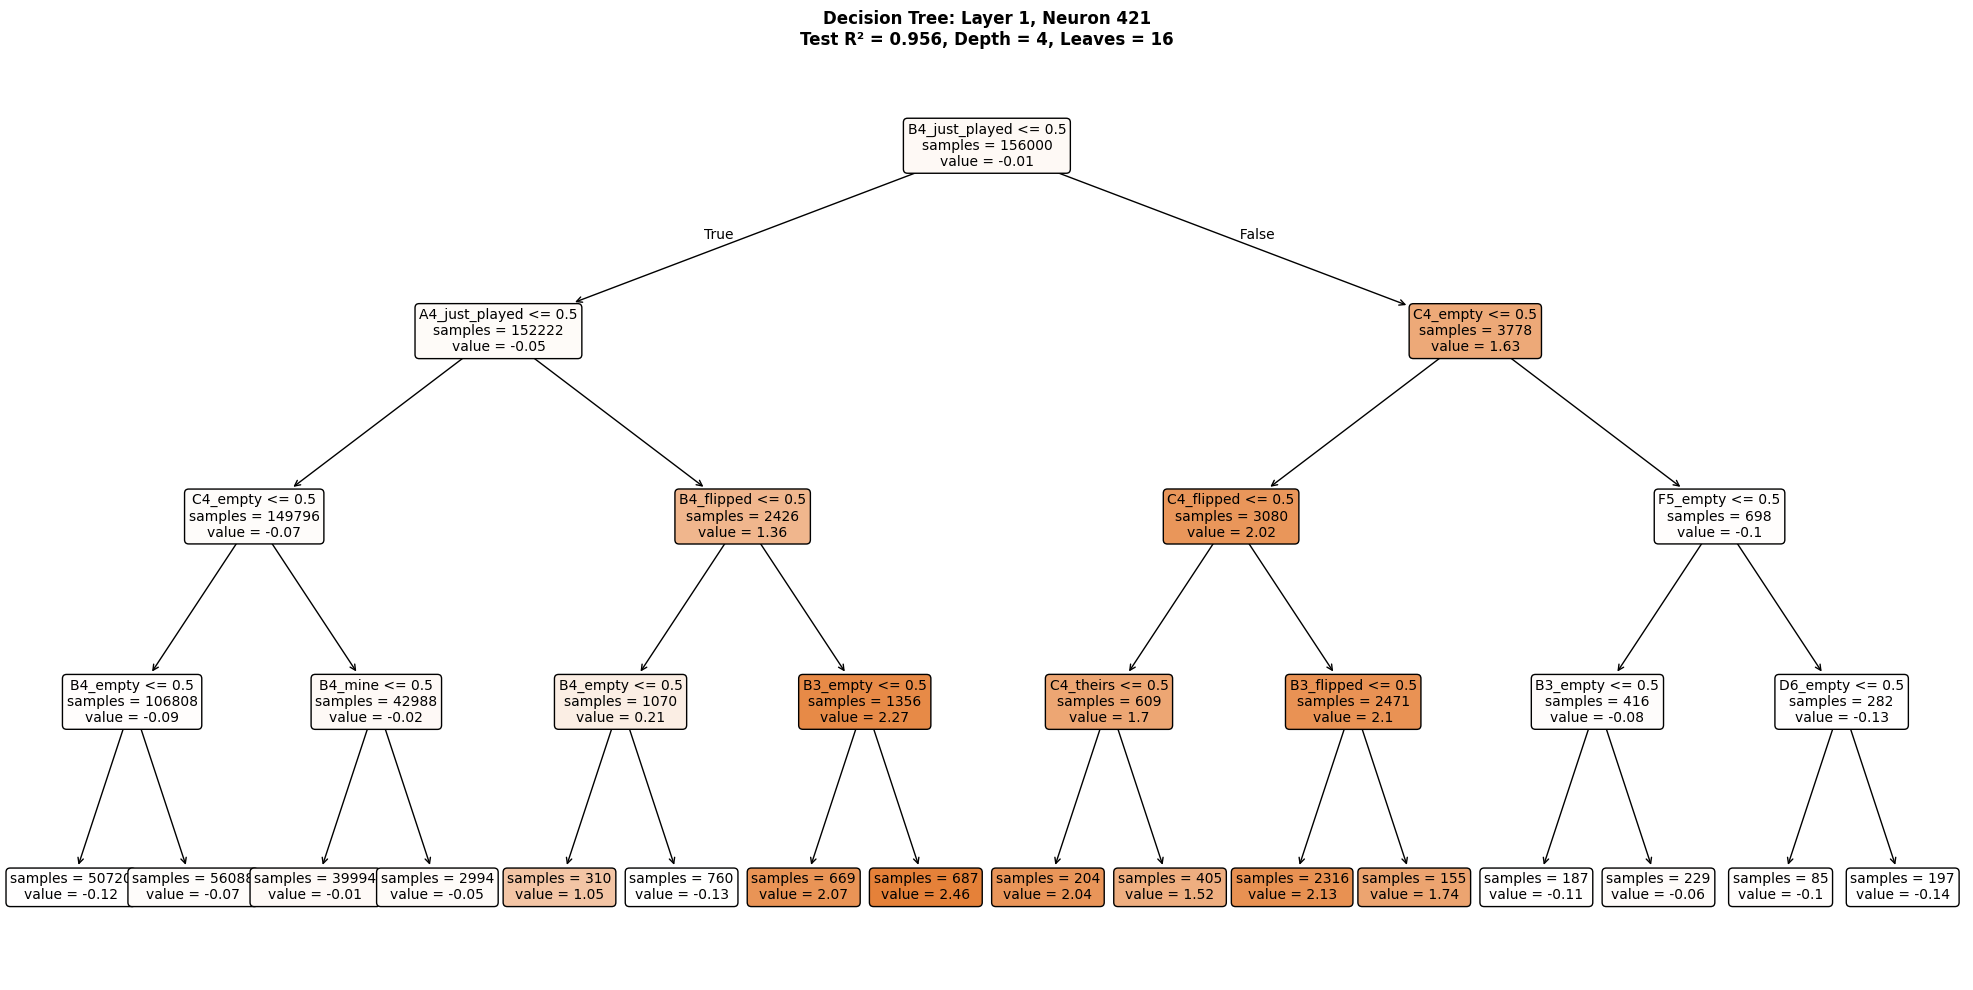


3. Extracting ON branches (OR-of-ANDs structure)...

Found 7 ON branches:

Branch 1 (AND conditions):
  - A4_just_played
  - NOT B4_empty
  - NOT B4_flipped
  - NOT B4_just_played

Branch 2 (AND conditions):
  - A4_just_played
  - B4_flipped
  - NOT B3_empty
  - NOT B4_just_played

Branch 3 (AND conditions):
  - A4_just_played
  - B3_empty
  - B4_flipped
  - NOT B4_just_played

Branch 4 (AND conditions):
  - B4_just_played
  - NOT C4_empty
  - NOT C4_flipped
  - NOT C4_theirs

Branch 5 (AND conditions):
  - B4_just_played
  - C4_theirs
  - NOT C4_empty
  - NOT C4_flipped

Branch 6 (AND conditions):
  - B4_just_played
  - C4_flipped
  - NOT B3_flipped
  - NOT C4_empty

Branch 7 (AND conditions):
  - B3_flipped
  - B4_just_played
  - C4_flipped
  - NOT C4_empty



In [6]:
# Example: Visualize a specific neuron
layer = 1
neuron = 421

tree_results, on_branches = visualize_neuron(layer, neuron)

## Part 2: Rule → Neuron

Search for neurons that satisfy specific rule conditions.

A rule is represented as a set of feature conditions (e.g., `{"C0_empty", "NOT D1_empty"}`)

In [7]:
@lru_cache(maxsize=1)
def load_all_trees(n_layers: int = 8) -> dict[int, list[dtypes.DecisionTreeResults]]:
    """Load and cache all decision trees from disk (called only once)"""
    print("Loading all decision trees from disk... (this will happen only once)")
    all_trees = {}
    for layer in range(n_layers):
        file_path = Path(f"decision_trees/ground_truth_features/regression/results/layer_{layer}_trees.pkl.gz")
        print(f"  Loading layer {layer}...")
        with gzip.open(file_path, 'rb') as f:
            all_trees[layer] = pickle.load(f)
    print("Done loading all trees!")
    return all_trees


def check_neuron(tree: dtypes.DecisionTreeResults, query: set[str]) -> bool:
    """
    Check if a neuron's ON conditions guarantee the query conditions.
    Returns True if any ON branch contains all query conditions.
    """
    decision_tree = tree.tree
    on_paths = process_neuron(decision_tree)

    # Is query a subset of any on path?
    return any(query <= path for path in on_paths)


def check_layer(trees: list[dtypes.DecisionTreeResults], query: set[str]) -> list[int]:
    """Return neuron indices in a layer that satisfy the query"""
    return [
        neuron_id
        for neuron_id, neuron_tree in enumerate(trees)
        if check_neuron(neuron_tree, query)
    ]


def check_model(trees: dict[int, list[dtypes.DecisionTreeResults]], query: set[str]) -> dict[int, list[int]]:
    """Return all neurons in all layers that satisfy the query"""
    return {
        layer: check_layer(layer_trees, query)
        for layer, layer_trees in trees.items()
    }


def find_neurons_for_query(query: set[str]) -> dict[int, list[int]]:
    """
    Find all neurons across all layers that satisfy the query.

    Args:
        query: Set of feature conditions (e.g., {"C0_empty", "NOT D1_empty"})

    Returns:
        Dictionary mapping layer index to list of neuron indices
    """
    all_trees = load_all_trees()
    return check_model(all_trees, query)

In [8]:
# Example: Find neurons that activate when C0 is empty AND D1 is NOT empty
query = {"C0_empty", "D1_theirs"}

print(f"Searching for neurons matching query: {query}\n")
results = find_neurons_for_query(query)

# Print results
total_neurons = 0
for layer, neurons in results.items():
    if neurons:
        print(f"Layer {layer}: {len(neurons)} neurons")
        print(f"  Neuron indices: {neurons[:10]}{'...' if len(neurons) > 10 else ''}")
        total_neurons += len(neurons)

print(f"\nTotal neurons matching query: {total_neurons}")

Searching for neurons matching query: {'C0_empty', 'D1_theirs'}

Loading all decision trees from disk... (this will happen only once)
  Loading layer 0...
  Loading layer 1...
  Loading layer 2...
  Loading layer 3...
  Loading layer 4...
  Loading layer 5...
  Loading layer 6...
  Loading layer 7...
Done loading all trees!
Layer 0: 2 neurons
  Neuron indices: [783, 1638]
Layer 1: 1 neurons
  Neuron indices: [54]
Layer 3: 1 neurons
  Neuron indices: [748]
Layer 4: 3 neurons
  Neuron indices: [151, 659, 1810]
Layer 5: 9 neurons
  Neuron indices: [212, 249, 432, 795, 838, 1348, 1393, 1622, 1952]
Layer 6: 15 neurons
  Neuron indices: [130, 255, 302, 349, 364, 386, 466, 700, 868, 961]...
Layer 7: 4 neurons
  Neuron indices: [5, 710, 768, 1014]

Total neurons matching query: 35



Visualizing first matching neuron: Layer 3, Neuron 249

Analyzing Layer 5, Neuron 249

1. Computing cosine similarities with probe directions...



2. Loading and visualizing ground truth decision tree...
   Test R²: 0.9449
   Tree depth: 4
   Number of leaves: 16


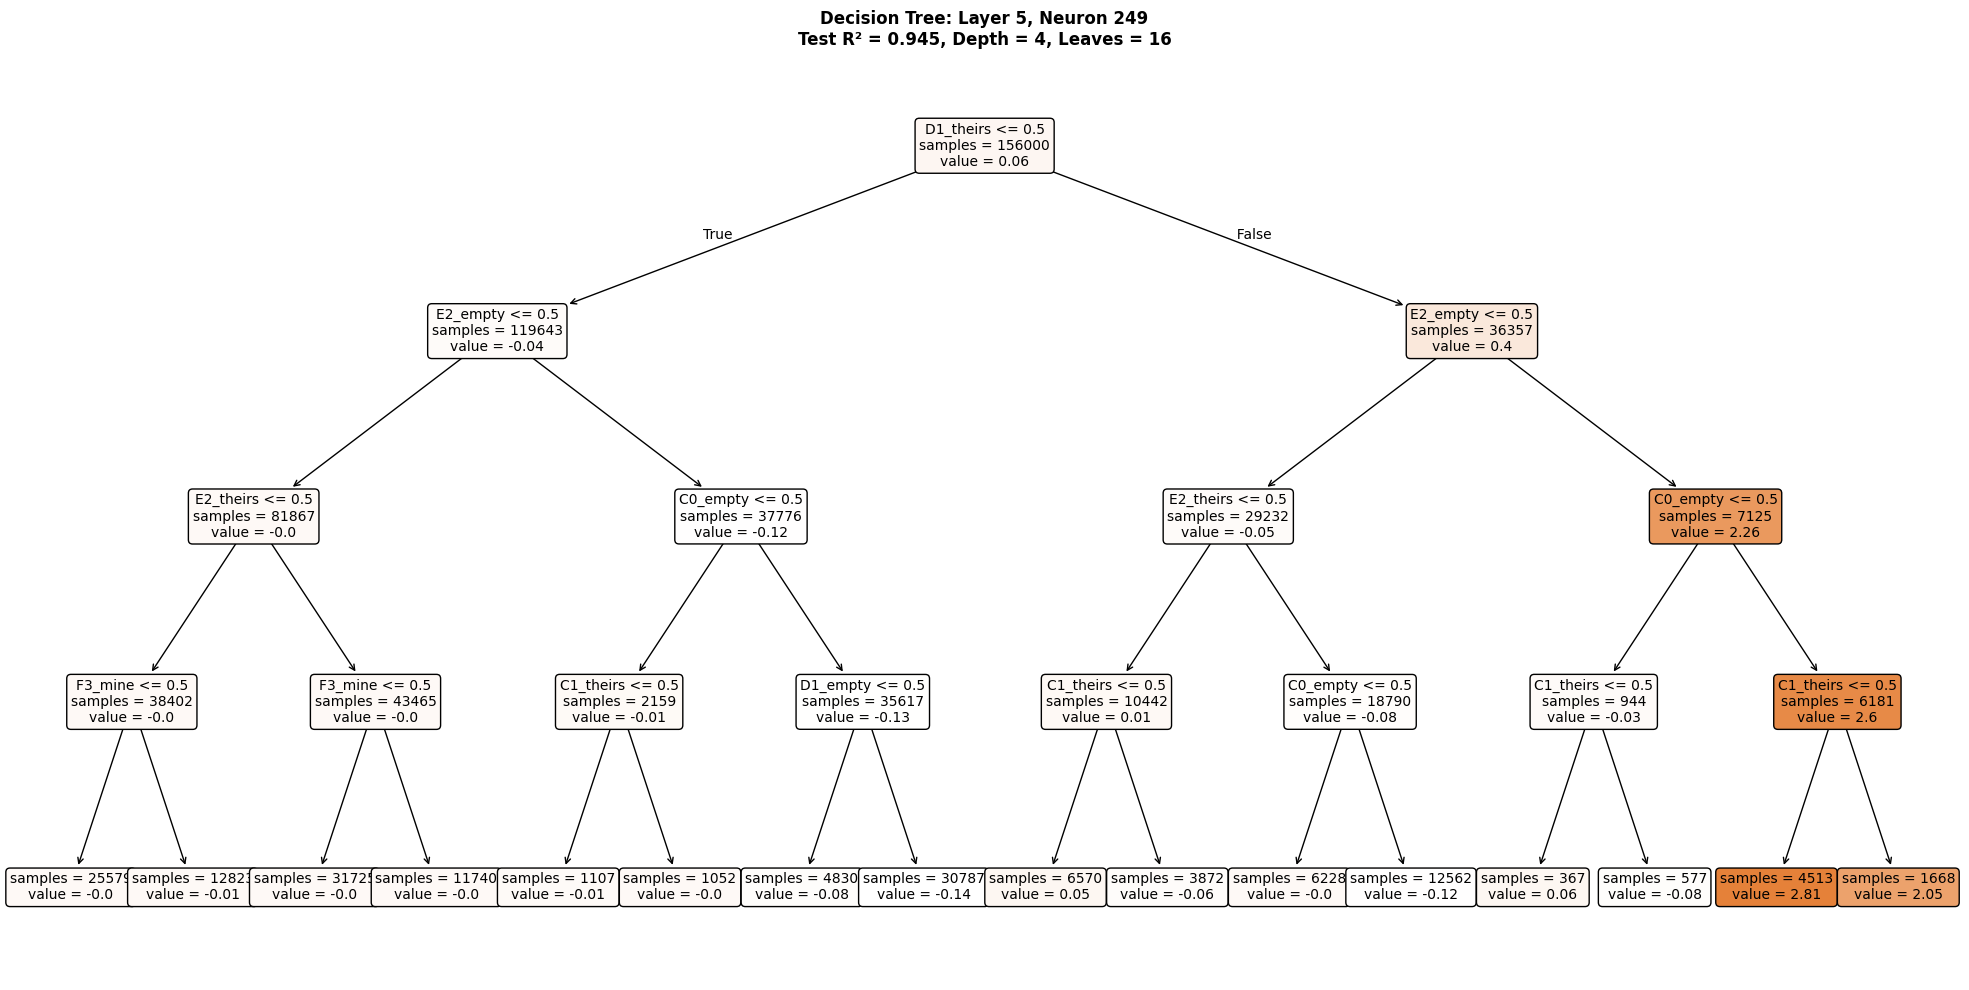


3. Extracting ON branches (OR-of-ANDs structure)...

Found 3 ON branches:

Branch 1 (AND conditions):
  - D1_theirs
  - E2_empty
  - NOT C0_empty
  - NOT C1_theirs

Branch 2 (AND conditions):
  - C0_empty
  - D1_theirs
  - E2_empty
  - NOT C1_theirs

Branch 3 (AND conditions):
  - C0_empty
  - C1_theirs
  - D1_theirs
  - E2_empty



(DecisionTreeResults(layer=5, neuron=249, tree=DecisionTreeRegressor(max_depth=4, min_samples_leaf=50, min_samples_split=100,
                       random_state=42), train_R2=0.9416734564750555, train_MSE=0.01699689298019197, test_R2=0.9448701194428815, test_MSE=0.019226196674881058),
 [{'D1_theirs', 'E2_empty', 'NOT C0_empty', 'NOT C1_theirs'},
  {'C0_empty', 'D1_theirs', 'E2_empty', 'NOT C1_theirs'},
  {'C0_empty', 'C1_theirs', 'D1_theirs', 'E2_empty'}])

In [9]:
# Example: Visualize one of the neurons that matches the query
example_neuron = results[5][1]
print(f"\nVisualizing first matching neuron: Layer 3, Neuron {example_neuron}")
visualize_neuron(5, example_neuron)

## Part 3: Ablation Experiments with Intervention/Control Logic

Let's test the causal importance of the neurons we found in the last section! We compare:
- **Intervention group**: Positions where C0 is legal along a diagonal
- **Control group**: Position where C0 is legal along a row

The goal is to corrupt performance in the intervention group while preserving in the control group, by removing the {C0 empty, D1 mine} neurons

In [10]:
# Part 3: Fine-grained intervention experiments
# Copied exactly from OthelloUnderstanding

from dataclasses import dataclass
from typing import Tuple
from nnsight import NNsight
from transformer_lens import HookedTransformer

# Load model exactly as in OthelloUnderstanding circuits/utils.py
#tf_model = HookedTransformer.from_pretrained("Baidicoot/Othello-GPT-Transformer-Lens")
model_nnsight = NNsight(model).to(device)

print(f"Loaded model with nnsight (n_layers={model_nnsight.cfg.n_layers})")

Moving model to device:  cpu
Loaded model with nnsight (n_layers=8)


In [11]:
# Load test data
from utils.circuits_utils import construct_othello_dataset
from utils.othello_utils import games_batch_to_state_stack_mine_yours_BLRRC

test_size = 500
custom_functions = [games_batch_to_state_stack_mine_yours_BLRRC]

test_data = construct_othello_dataset(
    custom_functions=custom_functions,
    n_inputs=test_size,
    split="test",
    device=device,
)

encoded_inputs = t.tensor(test_data["encoded_inputs"]).long()
decoded_inputs = t.tensor(test_data["decoded_inputs"]).long()
features = test_data["games_batch_to_state_stack_mine_yours_BLRRC"]

print(f"Loaded {test_size} test games")
print(f"Features shape: {features.shape}")  # [batch, seq, 8, 8, 3]

Generating train split:   0%|          | 0/792498 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/198125 [00:00<?, ? examples/s]

Precomputing games_batch_to_state_stack_mine_yours_BLRRC...


100%|██████████| 500/500 [00:04<00:00, 104.07it/s]

Loaded 500 test games
Features shape: torch.Size([500, 59, 8, 8, 3])


In [12]:
# Define experiment setup for square C0
legal_square = "C0"

# Intervention: C0 empty, D1 theirs, E2 mine (diagonal toward center)
intervention_query = {'C0_empty', 'D1_theirs', 'E2_mine'}

# Control: C0 empty, C1 theirs, C2 mine (axial toward center)
control_query = {'C0_empty', 'C1_theirs', 'C2_mine'}

# DT queries: Only use first TWO squares (C0 empty, D1 theirs)
dt_queries = [{'C0_empty', 'D1_theirs'}]

print(f"Legal square: {legal_square}")
print(f"Intervention: {intervention_query}")
print(f"Control: {control_query}")
print(f"DT queries (for finding neurons): {dt_queries}")

Legal square: C0
Intervention: {'C0_empty', 'E2_mine', 'D1_theirs'}
Control: {'C0_empty', 'C1_theirs', 'C2_mine'}
DT queries (for finding neurons): [{'C0_empty', 'D1_theirs'}]


In [13]:
# Helper functions from OthelloUnderstanding
def get_feature_indices(query: set[str]) -> list[Tuple[int, int, int]]:
    """Convert query like {'C0_empty', 'D1_theirs'} to feature indices"""
    indices = []
    for condition in query:
        square, feature = condition.split("_")
        row, col = list(square)
        row = ord(row) - ord('A')
        col = int(col)

        mode = None
        if feature == 'empty':
            mode = 1
        elif feature == 'mine':
            mode = 0
        else:  # theirs
            mode = 2

        indices.append((row, col, mode))

    return indices

def get_filtered_positions(
    encoded_inputs: t.Tensor,
    decoded_inputs: t.Tensor,
    features: t.Tensor,
    intervention_query: set[str],
    control_query: set[str],
    intervention: bool
) -> Tuple[list, list]:
    """Filter positions matching intervention or control queries"""
    intervention_indices = get_feature_indices(intervention_query)
    control_indices = get_feature_indices(control_query)

    intervention_mask = (features[..., *(intervention_indices[0])] == 1) & \
                        (features[..., *(intervention_indices[1])] == 1) & \
                        (features[..., *(intervention_indices[2])] == 1)
    control_mask = (features[..., *(control_indices[0])] == 1) & \
                   (features[..., *(control_indices[1])] == 1) & \
                   (features[..., *(control_indices[2])] == 1)

    if intervention:
        mask = intervention_mask & ~control_mask
    else:
        mask = control_mask & ~intervention_mask

    mask[:, :5] = False
    mask[:, 31:] = False

    filtered_positions_encoded = []
    filtered_positions_decoded = []
    for game_idx in range(mask.shape[0]):
        indices = t.where(mask[game_idx])[0]
        for idx in indices:
            filtered_positions_encoded.append(encoded_inputs[game_idx, : idx + 1])
            filtered_positions_decoded.append(decoded_inputs[game_idx, : idx + 1])

    return filtered_positions_encoded, filtered_positions_decoded

# Get intervention and control positions
intervention_positions_enc, intervention_positions_dec = get_filtered_positions(
    encoded_inputs, decoded_inputs, features, intervention_query, control_query, intervention=True
)

control_positions_enc, control_positions_dec = get_filtered_positions(
    encoded_inputs, decoded_inputs, features, intervention_query, control_query, intervention=False
)

print(f"Intervention positions: {len(intervention_positions_enc)}")
print(f"Control positions: {len(control_positions_enc)}")

Intervention positions: 519
Control positions: 405


In [14]:
# Find neurons for the dt_queries (first TWO squares only)
print(f"Searching for neurons matching: {dt_queries[0]}\n")

neurons = {}
for query in dt_queries:
    neurons_for_query = find_neurons_for_query(query)
    for layer, neuron_list in neurons_for_query.items():
        if layer not in neurons:
            neurons[layer] = []
        neurons[layer].extend(neuron_list)

# Remove duplicates
for layer in neurons:
    neurons[layer] = list(set(neurons[layer]))

total_neurons = sum(len(neuron_list) for neuron_list in neurons.values())
print(f"Found {total_neurons} neurons:")
for layer, neuron_list in neurons.items():
    if neuron_list:
        print(f"  Layer {layer}: {len(neuron_list)} neurons - {neuron_list[:5]}{'...' if len(neuron_list) > 5 else ''}")

Searching for neurons matching: {'C0_empty', 'D1_theirs'}

Found 35 neurons:
  Layer 0: 2 neurons - [1638, 783]
  Layer 1: 1 neurons - [54]
  Layer 3: 1 neurons - [748]
  Layer 4: 3 neurons - [1810, 659, 151]
  Layer 5: 9 neurons - [1952, 1348, 838, 432, 1393]...
  Layer 6: 15 neurons - [1568, 961, 130, 386, 868]...
  Layer 7: 4 neurons - [768, 5, 710, 1014]


In [15]:
# Intervention functions - copied exactly from OthelloUnderstanding
from utils.arena_utils import to_id, to_square
from utils.helper_fns import get_board_states_and_legal_moves

@dataclass(frozen=True)
class InterventionMetrics:
    logit_diff: float = 0.0
    prob_diff: float = 0.0
    clean_accuracy: float = 0.0
    corrupted_accuracy: float = 0.0
    accuracy_diff: float = 0.0
    below_1_percent: float = 0.0
    below_5_percent: float = 0.0
    below_10_percent: float = 0.0

def get_legal_moves_batch(batch: list[t.Tensor]) -> list[list[int]]:
    """Copied from ground_truth_dt/utils.py"""
    legal_moves_per_position = []

    for pos in batch:
        squares = to_square(pos.cpu())
        squares_tensor = t.tensor(squares).unsqueeze(0)
        _, legal_moves_tensor, _ = get_board_states_and_legal_moves(squares_tensor)
        legal_squares = t.where(legal_moves_tensor[0, -1].flatten())[0].tolist()
        legal_token_ids = [to_id(sq) for sq in legal_squares]
        legal_moves_per_position.append(legal_token_ids)

    return legal_moves_per_position

def right_pad(batch: list[t.Tensor], device: str):
    """Copied from ground_truth_dt/utils.py"""
    batch_indices = t.arange(len(batch), device=device)
    seq_lengths = [pos.shape[0] for pos in batch]
    last_token_indices = t.tensor([length - 1 for length in seq_lengths], device=device)
    max_len = max(seq_lengths)

    padded_batch = []
    for pos, length in zip(batch, seq_lengths):
        if length < max_len:
            padding = t.zeros(max_len - length, dtype=pos.dtype, device=pos.device)
            padded = t.cat([pos, padding])
        else:
            padded = pos
        padded_batch.append(padded)

    batch_tensor = t.stack(padded_batch).to(device)
    return batch_tensor, batch_indices, last_token_indices

def no_ablation(model, batch_tensor, batch_indices, last_token_indices, legal_square_id):
    """Copied from ground_truth_dt/utils.py"""
    with model.trace(batch_tensor):
        logits = model.unembed.output[batch_indices, last_token_indices].save()
        probs = t.nn.functional.softmax(logits, dim=-1)

        logits_square = logits[:, legal_square_id].save()
        probs_square = probs[:, legal_square_id].save()

    return logits, logits_square, probs_square

def zero_ablation(model, batch_tensor, batch_indices, last_token_indices, legal_square_id, neurons):
    """Copied from intervention_corrupt.py"""
    with model.trace(batch_tensor):
        for layer in range(0, model.cfg.n_layers - 1):
            if neurons.get(layer):
                neuron_indices = t.tensor(neurons[layer], device=batch_tensor.device)
                n_neurons = len(neurons[layer])
                batch_indices_repeated = einops.repeat(
                    batch_indices, 'batch -> batch neurons', neurons=n_neurons
                )
                last_token_indices_repeated = einops.repeat(
                    last_token_indices, 'batch -> batch neurons', neurons=n_neurons
                )
                neuron_indices_repeated = einops.repeat(
                    neuron_indices, 'neurons -> batch neurons', batch=len(batch_tensor)
                )
                model.blocks[layer].mlp.hook_post.output[
                    batch_indices_repeated, last_token_indices_repeated, neuron_indices_repeated
                ] = 0

        logits = model.unembed.output[batch_indices, last_token_indices].save()
        probs = t.nn.functional.softmax(logits, dim=-1)

        logits_square = logits[:, legal_square_id].save()
        probs_square = probs[:, legal_square_id].save()

    return logits, logits_square, probs_square

print("Intervention functions loaded!")

Intervention functions loaded!


In [16]:
# Run interventions on both intervention and control groups
def is_accurate_batch(logits, legal_moves_batch, legal_square_id):
    """Check if legal square is in top K logits where K = number of legal moves"""
    accurate = []
    for j, legal_moves in enumerate(legal_moves_batch):
        k = len(legal_moves)
        top_k_tokens = logits[j].topk(k=k).indices.tolist()
        accurate.append(legal_square_id in top_k_tokens)
    return accurate

def below_threshold(probs_square, legal_moves_batch, alpha=0.01):
    """Check if probability is below alpha * uniform"""
    return [(prob < alpha * 1 / len(legal_moves)).item()
            for prob, legal_moves in zip(probs_square, legal_moves_batch)]

def run_intervention(positions, legal_square, neurons, batch_size=128):
    """Run intervention experiment"""
    legal_square_id = to_id(legal_square)

    total_logit_diff = 0
    total_prob_diff = 0
    total_clean_accuracy = 0
    total_corrupted_accuracy = 0
    total_below_1_percent = 0
    total_below_5_percent = 0
    total_below_10_percent = 0

    for i in range(0, len(positions), batch_size):
        batch = positions[i:i + batch_size]

        legal_moves_batch = get_legal_moves_batch(batch)
        batch_tensor, batch_indices, last_token_indices = right_pad(batch, device=device)

        clean_logits, clean_logits_square, clean_probs_square = no_ablation(
            model_nnsight, batch_tensor, batch_indices, last_token_indices, legal_square_id
        )

        corrupted_logits, corrupted_logits_square, corrupted_probs_square = zero_ablation(
            model_nnsight, batch_tensor, batch_indices, last_token_indices, legal_square_id, neurons
        )

        is_accurate_clean = is_accurate_batch(clean_logits, legal_moves_batch, legal_square_id)
        total_clean_accuracy += sum(is_accurate_clean)

        is_accurate_corrupted = is_accurate_batch(corrupted_logits, legal_moves_batch, legal_square_id)
        total_corrupted_accuracy += sum(is_accurate_corrupted)

        total_below_1_percent += sum(below_threshold(corrupted_probs_square, legal_moves_batch, alpha=0.01))
        total_below_5_percent += sum(below_threshold(corrupted_probs_square, legal_moves_batch, alpha=0.05))
        total_below_10_percent += sum(below_threshold(corrupted_probs_square, legal_moves_batch, alpha=0.1))

        total_logit_diff += (clean_logits_square - corrupted_logits_square).sum().item()
        total_prob_diff += (clean_probs_square - corrupted_probs_square).sum().item()

    return InterventionMetrics(
        logit_diff=total_logit_diff / len(positions),
        prob_diff=total_prob_diff / len(positions),
        clean_accuracy=total_clean_accuracy / len(positions),
        corrupted_accuracy=total_corrupted_accuracy / len(positions),
        accuracy_diff=(total_clean_accuracy - total_corrupted_accuracy) / len(positions),
        below_1_percent=total_below_1_percent / len(positions),
        below_5_percent=total_below_5_percent / len(positions),
        below_10_percent=total_below_10_percent / len(positions),
    )

print(f"Running intervention on {len(intervention_positions_enc)} positions...")
intervention_metrics = run_intervention(intervention_positions_enc, legal_square, neurons)

print(f"\nRunning control on {len(control_positions_enc)} positions...")
control_metrics = run_intervention(control_positions_enc, legal_square, neurons)

print("\nDone!")

Running intervention on 519 positions...

Running control on 405 positions...

Done!


In [17]:
# Display results table
from rich.table import Table
from rich.console import Console

def print_results_table(intervention_metrics, control_metrics):
    """Print intervention vs control metrics"""
    console = Console()
    table = Table(title="Intervention Results")

    table.add_column("Metric", style="", no_wrap=True)
    table.add_column("Intervention", justify="right", style="")
    table.add_column("Control", justify="right", style="")

    table.add_row("Logit Diff", f"{intervention_metrics.logit_diff:.4f}", f"{control_metrics.logit_diff:.4f}")
    table.add_row("Prob Diff", f"{intervention_metrics.prob_diff:.4f}", f"{control_metrics.prob_diff:.4f}")
    table.add_row("Clean Accuracy", f"{intervention_metrics.clean_accuracy:.2%}", f"{control_metrics.clean_accuracy:.2%}")
    table.add_row("Corrupted Accuracy", f"{intervention_metrics.corrupted_accuracy:.2%}", f"{control_metrics.corrupted_accuracy:.2%}")
    table.add_row("Accuracy Diff", f"{intervention_metrics.accuracy_diff:.2%}", f"{control_metrics.accuracy_diff:.2%}")
    table.add_row("Below 1 Percent Original", f"{intervention_metrics.below_1_percent:.2%}", f"{control_metrics.below_1_percent:.2%}")
    table.add_row("Below 5 Percent", f"{intervention_metrics.below_5_percent:.2%}", f"{control_metrics.below_5_percent:.2%}")
    table.add_row("Below 10 Percent", f"{intervention_metrics.below_10_percent:.2%}", f"{control_metrics.below_10_percent:.2%}")

    console.print(table)

print_results_table(intervention_metrics, control_metrics)

                Intervention Results                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Metric                   ┃ Intervention ┃ Control ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Logit Diff               │       0.5766 │  0.3526 │
│ Prob Diff                │       0.0341 │  0.0225 │
│ Clean Accuracy           │      100.00% │ 100.00% │
│ Corrupted Accuracy       │      100.00% │ 100.00% │
│ Accuracy Diff            │        0.00% │   0.00% │
│ Below 1 Percent Original │        0.00% │   0.00% │
│ Below 5 Percent          │        0.77% │   0.00% │
│ Below 10 Percent         │        1.54% │   0.49% │
└──────────────────────────┴──────────────┴─────────┘